In [1]:
!pip install statsmodels matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
  Using cached statsmodels-0.14.6-cp313-cp313-win_amd64.whl.metadata (9.8 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
Using cached statsmodels-0.14.6-cp313-cp313-win_amd64.whl (9.5 MB)
Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\geova\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

# Carregar os dados
df = pd.read_csv("conjoint_survey_resp_v1.csv")

# Verificar se carregou corretamente
print(df.shape)  # esperado: (840, 17)
print(df.head(4))

(840, 17)
   Unnamed: 0  resp.id  ques       alt             Price        Brand  \
0           0        1     1  Option 1     Value(3€-10€)        Cavit   
1           1        1     1  Option 2  Popular(10€-15€)  Mezzacorona   
2           2        1     1  Option 3  Premium(15€-30€)      Ferrari   
3           3        1     1  Option 4  Popular(10€-15€)      Ferrari   

  Type of Wine Percentage of Alcohol Aging time of Wine  Age     Sex  \
0   White wine                 5.5 %            3 years    1  Female   
1   White wine                  18 %            1 year     1  Female   
2    Rose wine                  12 %            1 year     1  Female   
3    Rose wine                  18 %            4 years    1  Female   

  Employment status Education Ethnicity Social Platforms Physical Activities  \
0           Student   Masters    German        Instagram            Moderate   
1           Student   Masters    German        Instagram            Moderate   
2           Student   M

###  Remover coluna desnecessária

In [3]:
df = df.drop(columns=["Unnamed: 0"])

#### Remover espaços extras:

In [4]:
df["Aging time of Wine"] = df["Aging time of Wine"].str.strip()
df["Percentage of Alcohol"] = df["Percentage of Alcohol"].str.strip()

###  Verificar: 

In [5]:
print(df.shape)
print(df.columns.tolist())

(840, 16)
['resp.id', 'ques', 'alt', 'Price', 'Brand', 'Type of Wine', 'Percentage of Alcohol', 'Aging time of Wine', 'Age', 'Sex', 'Employment status', 'Education', 'Ethnicity', 'Social Platforms', 'Physical Activities', 'Choice']


###  Definir a ordem dos níveis de cada atributo.

In [6]:
# Definir categorias e referências de cada atributo

# PREÇO: referência = Luxury (o mais caro)
df["Price"] = pd.Categorical(df["Price"],
    categories=["Luxury(50€-100€)", "Value(3€-10€)", 
                 "Popular(10€-15€)", "Premium(15€-30€)"])

# MARCA: referência = Cavit
df["Brand"] = pd.Categorical(df["Brand"],
    categories=["Cavit", "Ferrari", "Mezzacorona", "Cantina Toblino"])

# TIPO: referência = Red wine
df["Type of Wine"] = pd.Categorical(df["Type of Wine"],
    categories=["Red wine", "White wine", "Rose wine", "Sparkling wine"])

# ÁLCOOL: referência = 18% (o mais alto)
df["Percentage of Alcohol"] = pd.Categorical(df["Percentage of Alcohol"],
    categories=["18 %", "5.5 %", "7 %", "12 %"])

# ENVELHECIMENTO: referência = 5 years
df["Aging time of Wine"] = pd.Categorical(df["Aging time of Wine"],
    categories=["5 years", "1 year", "2 years", "3 years", "4 years"])

print("Categorias definidas com sucesso!")

Categorias definidas com sucesso!


### Criar ID único para cada conjunto de escolha

In [7]:
# Criar ID único para cada conjunto de escolha
# (combinação de respondente + questão)
df["chid"] = df["resp.id"].astype(str) + "_" + df["ques"].astype(str)

print("Choice sets únicos:", df["chid"].nunique())
# Esperado: 210 (30 respondentes × 7 questões)

Choice sets únicos: 210


### Modelo de Análise Conjunta.

In [8]:
import statsmodels.formula.api as smf

# Criar variáveis dummy para cada atributo
# (transforma texto em números para o modelo entender)
dummies = pd.get_dummies(df[["Price", "Brand", "Type of Wine", 
                              "Percentage of Alcohol", 
                              "Aging time of Wine"]], 
                          drop_first=True)

# Juntar com as colunas principais
df_model = pd.concat([df[["chid", "alt", "Choice"]], dummies], axis=1)

print("Dados prontos para o modelo!")
print("Colunas:", df_model.shape)

Dados prontos para o modelo!
Colunas: (840, 19)


In [9]:
from statsmodels.discrete.conditional_models import ConditionalLogit

# Separar variáveis independentes (atributos) e dependente (escolha)
X = df_model.drop(columns=["chid", "alt", "Choice"])
y = df_model["Choice"]
grupos = df_model["chid"]

# Rodar o modelo
modelo = ConditionalLogit(y, X, groups=grupos)
resultado = modelo.fit()

print(resultado.summary())

                  Conditional Logit Model Regression Results                  
Dep. Variable:                 Choice   No. Observations:                  840
Model:               ConditionalLogit   No. groups:                        210
Log-Likelihood:               -260.09   Min group size:                      4
Method:                          BFGS   Max group size:                      4
Date:                Sun, 10 May 2026   Mean group size:                   4.0
Time:                        17:26:00                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Price_Value(3€-10€)             1.4238      0.286      4.985      0.000       0.864       1.984
Price_Popular(10€-15€)          1.5038      0.275      5.478      0.000       0.966       2.042
Price_Premium(15€-30€)          1.0343      0.294      3.512   

### Calcular as importâncias relativas de cada atributo.

In [10]:
# Extrair os coeficientes do modelo
coefs = resultado.params

# Calcular o range de cada atributo
# (diferença entre o maior e o menor coeficiente)
ranges = {
    "Preço":          max(0, coefs["Price_Value(3€-10€)"], coefs["Price_Popular(10€-15€)"], coefs["Price_Premium(15€-30€)"]) - min(0, coefs["Price_Value(3€-10€)"], coefs["Price_Popular(10€-15€)"], coefs["Price_Premium(15€-30€)"]),
    "Marca":          max(0, coefs["Brand_Ferrari"], coefs["Brand_Mezzacorona"], coefs["Brand_Cantina Toblino"]) - min(0, coefs["Brand_Ferrari"], coefs["Brand_Mezzacorona"], coefs["Brand_Cantina Toblino"]),
    "Tipo de Vinho":  max(0, coefs["Type of Wine_White wine"], coefs["Type of Wine_Rose wine"], coefs["Type of Wine_Sparkling wine"]) - min(0, coefs["Type of Wine_White wine"], coefs["Type of Wine_Rose wine"], coefs["Type of Wine_Sparkling wine"]),
    "Teor Alcoólico": max(0, coefs["Percentage of Alcohol_5.5 %"], coefs["Percentage of Alcohol_7 %"], coefs["Percentage of Alcohol_12 %"]) - min(0, coefs["Percentage of Alcohol_5.5 %"], coefs["Percentage of Alcohol_7 %"], coefs["Percentage of Alcohol_12 %"]),
    "Envelhecimento": max(0, coefs["Aging time of Wine_1 year"], coefs["Aging time of Wine_2 years"], coefs["Aging time of Wine_3 years"], coefs["Aging time of Wine_4 years"]) - min(0, coefs["Aging time of Wine_1 year"], coefs["Aging time of Wine_2 years"], coefs["Aging time of Wine_3 years"], coefs["Aging time of Wine_4 years"])
}

# Calcular importâncias percentuais
total = sum(ranges.values())
importancias = {k: round(v/total*100, 1) for k, v in ranges.items()}

# Mostrar ordenado
for k, v in sorted(importancias.items(), key=lambda x: -x[1]):
    print(f"{k}: {v}%")


Preço: 42.1%
Marca: 24.5%
Envelhecimento: 13.6%
Teor Alcoólico: 10.9%
Tipo de Vinho: 9.0%


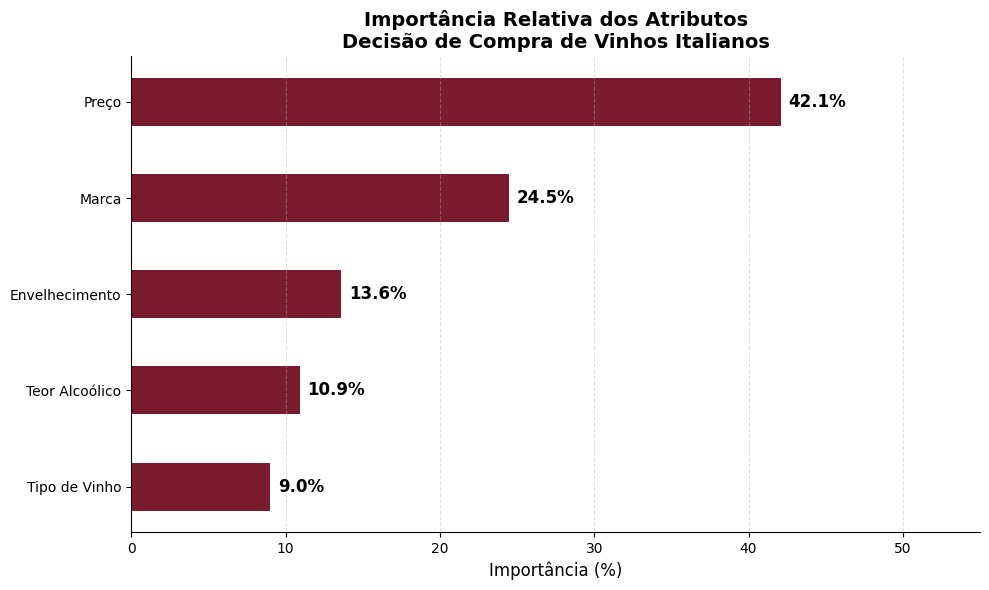

In [11]:
import matplotlib.pyplot as plt

# Organizar os dados ordenados por importância
atributos = list(sorted(importancias.items(), key=lambda x: -x[1]))
nomes = [x[0] for x in atributos]
valores = [x[1] for x in atributos]

# Criar o gráfico
fig, ax = plt.subplots(figsize=(10, 6))

barras = ax.barh(nomes, valores, color="#7a1c2e", height=0.5)

# Adicionar os valores nas barras
for barra, valor in zip(barras, valores):
    ax.text(barra.get_width() + 0.5, barra.get_y() + barra.get_height()/2,
            f"{valor}%", va="center", fontweight="bold", fontsize=12)

# Formatação
ax.set_xlabel("Importância (%)", fontsize=12)
ax.set_title("Importância Relativa dos Atributos\nDecisão de Compra de Vinhos Italianos",
             fontsize=14, fontweight="bold")
ax.set_xlim(0, 55)
ax.invert_yaxis()
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("importancias_atributos.png", dpi=150)
plt.show()

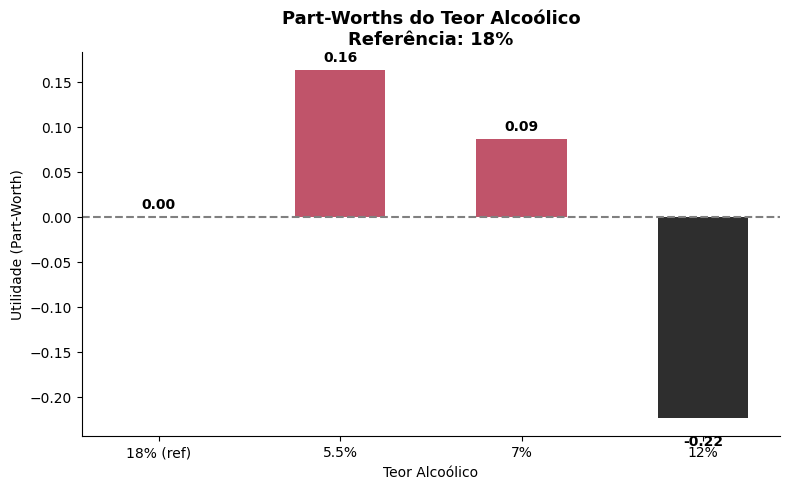

In [12]:
# Part-worths do Álcool
alcool = {
    "18% (ref)": 0,
    "5.5%": coefs["Percentage of Alcohol_5.5 %"],
    "7%":   coefs["Percentage of Alcohol_7 %"],
    "12%":  coefs["Percentage of Alcohol_12 %"]
}

nomes_alc = list(alcool.keys())
valores_alc = list(alcool.values())
cores = ["#c0546a" if v >= 0 else "#2e2e2e" for v in valores_alc]

fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.bar(nomes_alc, valores_alc, color=cores, width=0.5)

ax.axhline(0, color="gray", linestyle="--")
ax.set_title("Part-Worths do Teor Alcoólico\nReferência: 18%",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Utilidade (Part-Worth)")
ax.set_xlabel("Teor Alcoólico")

for barra, valor in zip(barras, valores_alc):
    ax.text(barra.get_x() + barra.get_width()/2,
            valor + 0.01 if valor >= 0 else valor - 0.03,
            f"{valor:.2f}", ha="center", fontweight="bold")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("h3_alcool.png", dpi=150)
plt.show()

In [13]:
# Separar os dados por gênero
df_female = df[df["Sex"] == "Female"]
df_male = df[df["Sex"] == "Male"]

print("Linhas Feminino:", len(df_female))
print("Linhas Masculino:", len(df_male))

Linhas Feminino: 364
Linhas Masculino: 476


In [14]:
# Criar dummies para cada gênero separado
def preparar_dados(df_genero):
    dummies = pd.get_dummies(df_genero[["Price", "Brand", "Type of Wine", 
                                        "Percentage of Alcohol", 
                                        "Aging time of Wine"]], 
                              drop_first=True)
    df_m = pd.concat([df_genero[["chid", "alt", "Choice"]].reset_index(drop=True), 
                      dummies.reset_index(drop=True)], axis=1)
    return df_m

df_f = preparar_dados(df_female)
df_m = preparar_dados(df_male)

# Rodar modelo feminino
modelo_f = ConditionalLogit(df_f["Choice"], 
                             df_f.drop(columns=["chid","alt","Choice"]), 
                             groups=df_f["chid"])
resultado_f = modelo_f.fit(disp=False)

# Rodar modelo masculino
modelo_m = ConditionalLogit(df_m["Choice"], 
                             df_m.drop(columns=["chid","alt","Choice"]), 
                             groups=df_m["chid"])
resultado_m = modelo_m.fit(disp=False)

print("Modelos rodados com sucesso!")

Modelos rodados com sucesso!


In [15]:
def calcular_importancia_preco(resultado):
    coefs = resultado.params
    
    ranges = {
        "Preço": max(0, coefs["Price_Value(3€-10€)"], 
                     coefs["Price_Popular(10€-15€)"], 
                     coefs["Price_Premium(15€-30€)"]) - 
                min(0, coefs["Price_Value(3€-10€)"], 
                     coefs["Price_Popular(10€-15€)"], 
                     coefs["Price_Premium(15€-30€)"]),
        "Marca": max(0, coefs["Brand_Ferrari"], 
                     coefs["Brand_Mezzacorona"], 
                     coefs["Brand_Cantina Toblino"]) - 
                min(0, coefs["Brand_Ferrari"], 
                     coefs["Brand_Mezzacorona"], 
                     coefs["Brand_Cantina Toblino"]),
        "Tipo de Vinho": max(0, coefs["Type of Wine_White wine"], 
                             coefs["Type of Wine_Rose wine"], 
                             coefs["Type of Wine_Sparkling wine"]) - 
                        min(0, coefs["Type of Wine_White wine"], 
                             coefs["Type of Wine_Rose wine"], 
                             coefs["Type of Wine_Sparkling wine"]),
        "Teor Alcoólico": max(0, coefs["Percentage of Alcohol_5.5 %"], 
                              coefs["Percentage of Alcohol_7 %"], 
                              coefs["Percentage of Alcohol_12 %"]) - 
                         min(0, coefs["Percentage of Alcohol_5.5 %"], 
                              coefs["Percentage of Alcohol_7 %"], 
                              coefs["Percentage of Alcohol_12 %"]),
        "Envelhecimento": max(0, coefs["Aging time of Wine_1 year"], 
                              coefs["Aging time of Wine_2 years"], 
                              coefs["Aging time of Wine_3 years"], 
                              coefs["Aging time of Wine_4 years"]) - 
                         min(0, coefs["Aging time of Wine_1 year"], 
                              coefs["Aging time of Wine_2 years"], 
                              coefs["Aging time of Wine_3 years"], 
                              coefs["Aging time of Wine_4 years"])
    }
    
    total = sum(ranges.values())
    return round(ranges["Preço"] / total * 100, 1)

imp_f = calcular_importancia_preco(resultado_f)
imp_m = calcular_importancia_preco(resultado_m)

print(f"Importância do Preço — Feminino: {imp_f}%")
print(f"Importância do Preço — Masculino: {imp_m}%")
print(f"Diferença: {abs(imp_f - imp_m)} pontos percentuais")

Importância do Preço — Feminino: 36.1%
Importância do Preço — Masculino: 42.9%
Diferença: 6.799999999999997 pontos percentuais


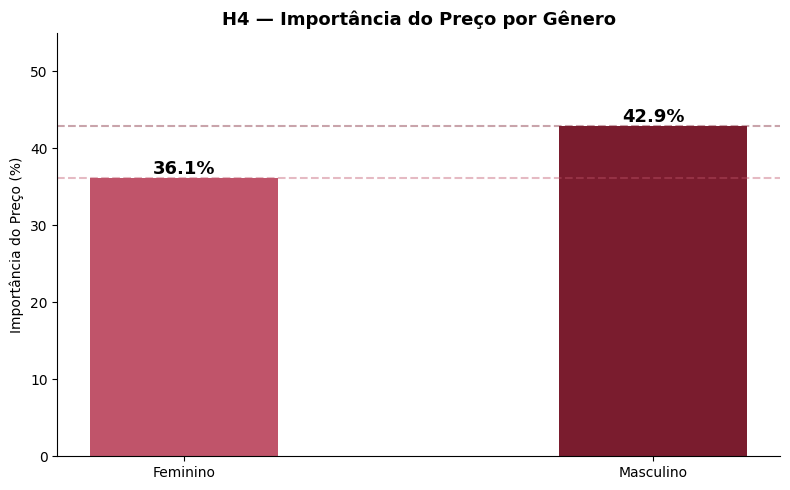

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))

generos = ["Feminino", "Masculino"]
valores = [imp_f, imp_m]
cores = ["#c0546a", "#7a1c2e"]

barras = ax.bar(generos, valores, color=cores, width=0.4)

# Adicionar valores nas barras
for barra, valor in zip(barras, valores):
    ax.text(barra.get_x() + barra.get_width()/2,
            barra.get_height() + 0.5,
            f"{valor}%", ha="center", 
            fontweight="bold", fontsize=13)

ax.set_title("H4 — Importância do Preço por Gênero",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Importância do Preço (%)")
ax.set_ylim(0, 55)
ax.axhline(y=imp_f, color="#c0546a", linestyle="--", alpha=0.4)
ax.axhline(y=imp_m, color="#7a1c2e", linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("h4_genero_preco.png", dpi=150)
plt.show()